Step 1: Ensure Libraries Are Installed and Imported

Ensure that all required libraries (e.g., scikit-learn, matplotlib, seaborn, pandas, numpy) are installed in your environment. If you are missing any of these libraries, you can install them using pip:

In [1]:
pip install pandas numpy scikit-learn seaborn matplotlib

Note: you may need to restart the kernel to use updated packages.


Next, we’ll start by importing everything in your notebook.

In [2]:
# Importing Libraries
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
import warnings

warnings.filterwarnings("ignore")

Step 2: Load the Dataset and Data Exploration

Make sure your dataset is correctly loaded. Ensure the file path is correct and the dataset is in CSV format. Let’s start by loading the data and performing initial exploration.

In [3]:
# Load the Dataset
data_path = '/Users/chandanapacha/Desktop/British Airways Project/customer_booking.csv'#keep path of file
df = pd.read_csv(data_path, encoding='ISO-8859-1')
print(df.head())  # Display the first few rows of the dataset

# Data Exploration
print("Data Types:\n", df.dtypes)
print("Shape of the Data:", df.shape)
print("Checking for Null Values:\n", df.isnull().sum())
print("Booking Completion Value Counts:\n", df['booking_complete'].value_counts())

   num_passengers sales_channel  trip_type  purchase_lead  length_of_stay  \
0               2      Internet  RoundTrip            262              19   
1               1      Internet  RoundTrip            112              20   
2               2      Internet  RoundTrip            243              22   
3               1      Internet  RoundTrip             96              31   
4               2      Internet  RoundTrip             68              22   

   flight_hour flight_day   route booking_origin  wants_extra_baggage  \
0            7        Sat  AKLDEL    New Zealand                    1   
1            3        Sat  AKLDEL    New Zealand                    0   
2           17        Wed  AKLDEL          India                    1   
3            4        Sat  AKLDEL    New Zealand                    0   
4           15        Wed  AKLDEL          India                    1   

   wants_preferred_seat  wants_in_flight_meals  flight_duration  \
0                     0        

Step 3: Correlation Matrix

Now, compute the correlation matrix to identify which features are most correlated with booking_complete.

Correlation Coefficients with booking_complete:
booking_complete         1.000000
wants_extra_baggage      0.068139
wants_preferred_seat     0.050116
wants_in_flight_meals    0.026511
num_passengers           0.024116
flight_hour              0.007127
purchase_lead           -0.022131
length_of_stay          -0.042408
flight_duration         -0.106266
Name: booking_complete, dtype: float64


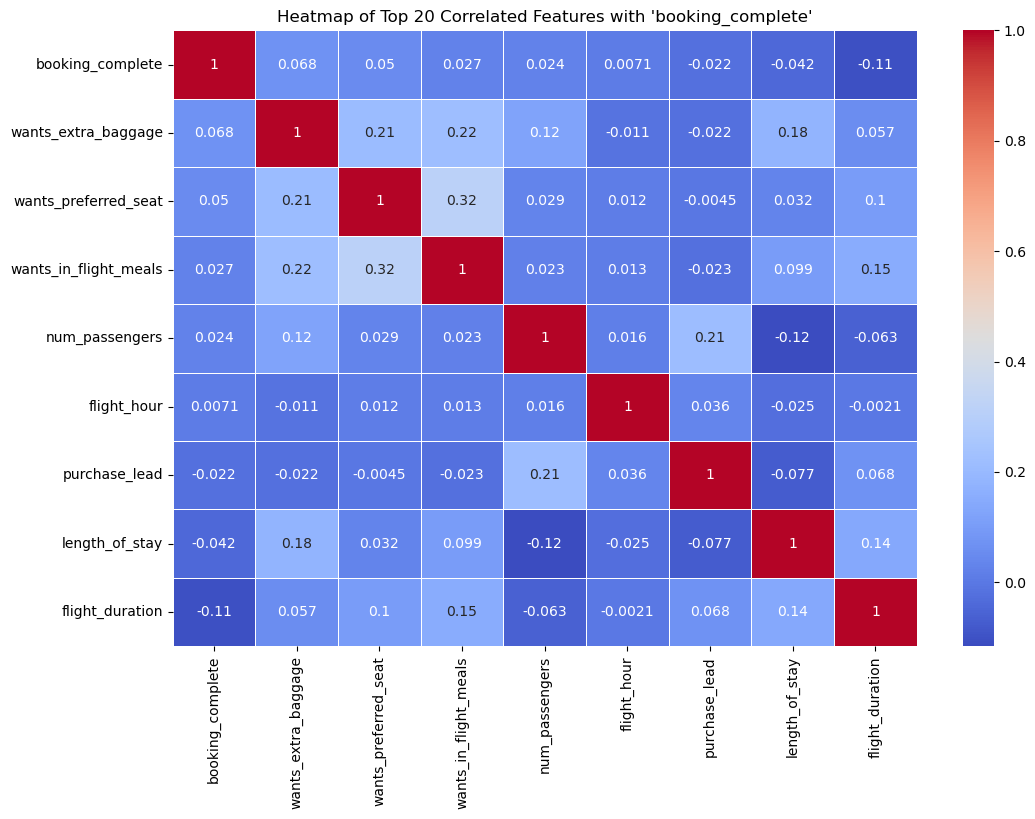

In [4]:
# Compute the Correlation Matrix
correlation_matrix = df.corr()

# Print the correlation coefficients with respect to the target variable 'booking_complete'
correlation_with_target = correlation_matrix['booking_complete'].sort_values(ascending=False)
print("Correlation Coefficients with booking_complete:")
print(correlation_with_target)

# Select top 20 most correlated features with 'booking_complete'
top_correlated_features = correlation_with_target.index[:9]  # Modify this number if you want more/less features

# Subset the correlation matrix for the selected features
top_correlation_matrix = df[top_correlated_features].corr()

# Create the heatmap with the top correlated features
plt.figure(figsize=(12, 8))
sns.heatmap(top_correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Heatmap of Top 20 Correlated Features with 'booking_complete'")
plt.show()

Step 4: Build Random Forest Models

First, we will build the Random Forest model using only the most correlated features.

In [5]:
# Select the most correlated features (change the threshold according to your needs)
correlated_features = correlation_with_target.index[1:6]  # Select top 5 most correlated features
print("Selected features for Random Forest based on correlation:\n", correlated_features)

# Prepare the data
X_corr = df[correlated_features]
y = df['booking_complete']

# Split the dataset
X_train_corr, X_test_corr, y_train_corr, y_test_corr = train_test_split(X_corr, y, test_size=0.2, random_state=42)

# Initialize and train the Random Forest model
rf_model_corr = RandomForestClassifier(random_state=42)
rf_model_corr.fit(X_train_corr, y_train_corr)

# Make predictions on the test set
rf_preds_corr = rf_model_corr.predict(X_test_corr)

# Evaluate the Random Forest model with most correlated features
print("\nRandom Forest (Top Correlated Features) Performance:")
print("Accuracy:", accuracy_score(y_test_corr, rf_preds_corr))
print("AUC Score:", roc_auc_score(y_test_corr, rf_preds_corr))
print("Classification Report:\n", classification_report(y_test_corr, rf_preds_corr))

Selected features for Random Forest based on correlation:
 Index(['wants_extra_baggage', 'wants_preferred_seat', 'wants_in_flight_meals',
       'num_passengers', 'flight_hour'],
      dtype='object')

Random Forest (Top Correlated Features) Performance:
Accuracy: 0.8491
AUC Score: 0.4996938840248699
Classification Report:
               precision    recall  f1-score   support

           0       0.85      1.00      0.92      8520
           1       0.13      0.00      0.01      1480

    accuracy                           0.85     10000
   macro avg       0.49      0.50      0.46     10000
weighted avg       0.74      0.85      0.78     10000



Then, build a Random Forest model using all features:

In [6]:
from sklearn.preprocessing import OneHotEncoder

# Prepare the data with all features
X_all = df.drop('booking_complete', axis=1)
y = df['booking_complete']

# One-Hot Encoding for categorical features
X_all = pd.get_dummies(X_all, drop_first=True)  # This will one-hot encode the categorical variables

# Split the dataset
X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(X_all, y, test_size=0.2, random_state=42)

# Initialize and train the Random Forest model
rf_model_all = RandomForestClassifier(random_state=42)
rf_model_all.fit(X_train_all, y_train_all)

# Make predictions on the test set
rf_preds_all = rf_model_all.predict(X_test_all)

# Evaluate the Random Forest model with all features
print("\nRandom Forest (All Features) Performance:")
print("Accuracy:", accuracy_score(y_test_all, rf_preds_all))
print("AUC Score:", roc_auc_score(y_test_all, rf_preds_all))
print("Classification Report:\n", classification_report(y_test_all, rf_preds_all))


Random Forest (All Features) Performance:
Accuracy: 0.8559
AUC Score: 0.5572817535845704
Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.98      0.92      8520
           1       0.55      0.13      0.21      1480

    accuracy                           0.86     10000
   macro avg       0.71      0.56      0.57     10000
weighted avg       0.82      0.86      0.82     10000



Step 5: Build Logistic Regression Model

Finally, build a Logistic Regression model:

In [7]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

# Prepare the data with all features
X_all = df.drop('booking_complete', axis=1)
y = df['booking_complete']

# One-Hot Encoding for categorical features
X_all = pd.get_dummies(X_all, drop_first=True)  # Convert categorical variables to numeric

# Check for any non-numeric columns
print(X_all.dtypes)

# Split the dataset into training and testing sets
X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(X_all, y, test_size=0.2, random_state=42)

# Initialize and train the Logistic Regression model
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_log, y_train_log)

# Make predictions on the test set
log_preds = log_model.predict(X_test_log)

# Evaluate the Logistic Regression model
print("\nLogistic Regression Performance:")
print("Accuracy:", accuracy_score(y_test_log, log_preds))
print("AUC Score:", roc_auc_score(y_test_log, log_preds))
print("Classification Report:\n", classification_report(y_test_log, log_preds))

num_passengers                         int64
purchase_lead                          int64
length_of_stay                         int64
flight_hour                            int64
wants_extra_baggage                    int64
                                       ...  
booking_origin_United Arab Emirates    uint8
booking_origin_United Kingdom          uint8
booking_origin_United States           uint8
booking_origin_Vanuatu                 uint8
booking_origin_Vietnam                 uint8
Length: 918, dtype: object

Logistic Regression Performance:
Accuracy: 0.8531
AUC Score: 0.5344229793173454
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.99      0.92      8520
           1       0.52      0.08      0.14      1480

    accuracy                           0.85     10000
   macro avg       0.69      0.53      0.53     10000
weighted avg       0.81      0.85      0.80     10000

